Predict Students' Dropout and Academic Success


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [17]:
# 1. Veri Setini Yükleme
df = pd.read_csv('data.csv', sep=';')
display(df.head(3))

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout


In [18]:
# 2. Hedef değişkeni ayırıyorum
X_raw = df.drop('Target', axis=1)
y = df['Target']

imputer = SimpleImputer(strategy="mean")
X_imputed = pd.DataFrame(imputer.fit_transform(X_raw), columns=X_raw.columns)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

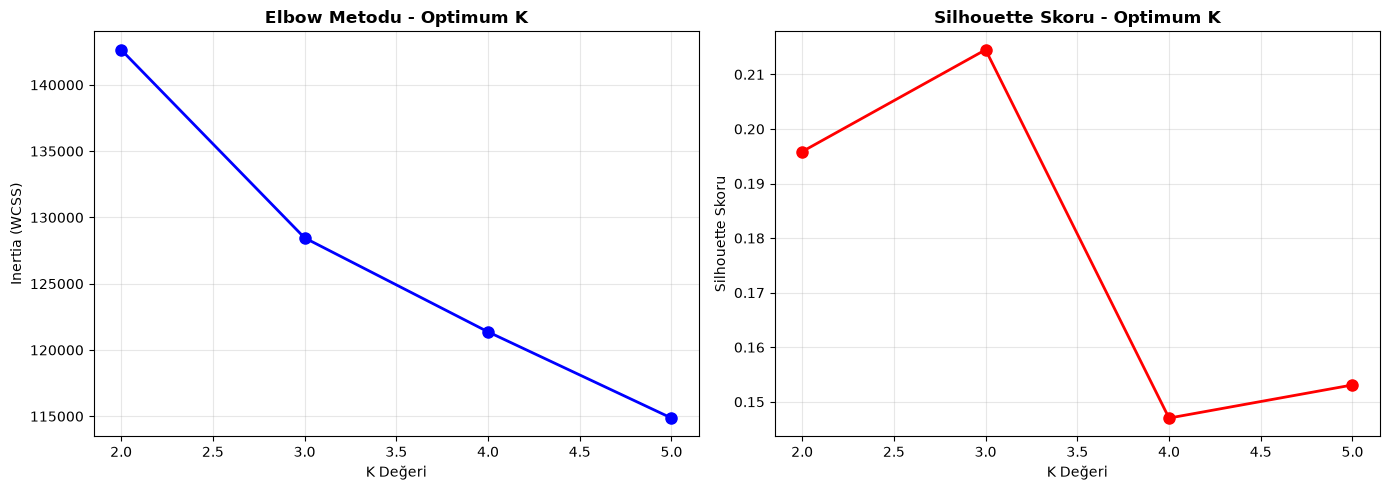

In [23]:
# KÜMELEME ANALİZİ & GÖRSELLEŞTİRME

# A) Optimum K için Elbow ve Silhouette Analizi
inertia = []
silhouette_scores = []
K_range = range(2, 6)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Metodu - Optimum K', fontweight='bold')
axes[0].set_xlabel('K Değeri')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Skoru - Optimum K', fontweight='bold')
axes[1].set_xlabel('K Değeri')
axes[1].set_ylabel('Silhouette Skoru')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

optimal_k = K_range[np.argmax(silhouette_scores)]

In [24]:
# B) Final K-Means Modeli ve Skorları
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

print(f'Optimum K Değeri: {optimal_k} | Silhouette: {silhouette_score(X_scaled, kmeans_labels):.4f}')

Optimum K Değeri: 3 | Silhouette: 0.2145


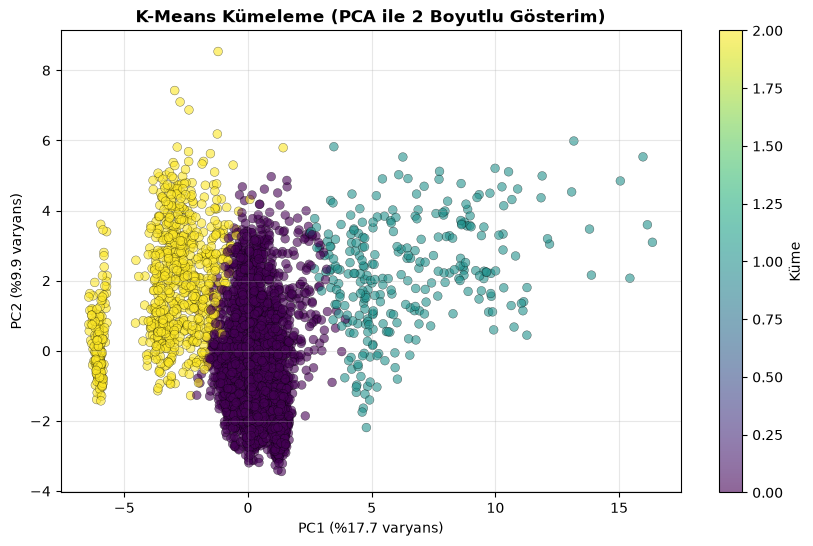

In [25]:
# C) PCA ile 2 Boyutlu K-Means Görselleştirme
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.6, s=40, edgecolors='k', linewidth=0.3)
plt.colorbar(scatter, label='Küme')
plt.title('K-Means Kümeleme (PCA ile 2 Boyutlu Gösterim)', fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)')
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)')
plt.grid(True, alpha=0.3)
plt.show()

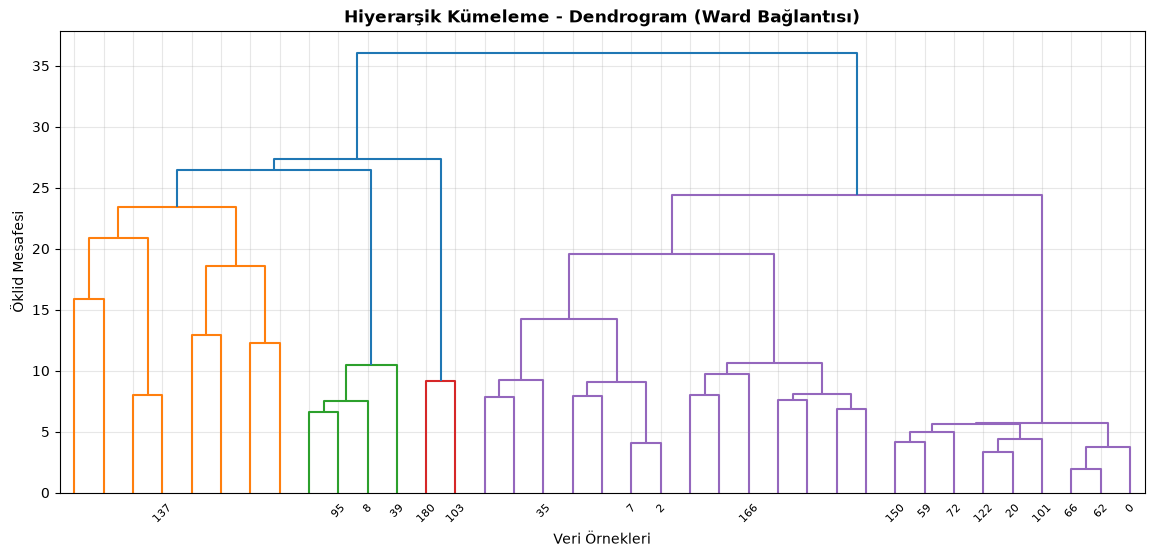

In [27]:
# D) Hiyerarşik Kümeleme - Dendrogram
plt.figure(figsize=(14, 6))
linked = linkage(X_scaled[:200], method='ward')
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=False, truncate_mode='level', p=5)
plt.title('Hiyerarşik Kümeleme - Dendrogram (Ward Bağlantısı)', fontweight='bold')
plt.xlabel('Veri Örnekleri')
plt.ylabel('Öklid Mesafesi')
plt.grid(True, alpha=0.3)
plt.show()

In [31]:
# SINIFLANDIRMA (Decision Tree & Random Forest)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

dt = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)

print(f"\nDecision Tree Doğruluk: {accuracy_score(y_test, dt.predict(X_test)):.4f}")
print(f"Random Forest Doğruluk: {accuracy_score(y_test, rf.predict(X_test)):.4f}")


Decision Tree Doğruluk: 0.6642
Random Forest Doğruluk: 0.7598
